# 第015讲 曲率与局部近似

## Goal 目标
在固定三条合成记录上，核对一阶与二阶 Taylor 近似、Hessian 与特征方向，分类驻点并测量近似误差。另用精确旋转二次型说明椭圆和统一步长的限制。先修第12、14讲。

已执行结果摘要：主点 Hessian 特征值为 −2/3、13/3，但梯度非零，不能叫驻点鞍点。驻点 (6/5,0) 是鞍点；(1/2,±√(7/6)) 的损失为1/18。普通方向的二阶误差约三次缩小，抵消方向为四次。浮点相减在极小位移失去这种趋势。

所有图、数值和测试仅演示数学机制，不是预测泛化结果。

## Setup 环境与契约
从本 Notebook 所在目录运行，保留同目录 experiment.py 和 data。真实验证使用 Python 3.12.14、NumPy 2.3.5、Matplotlib 3.10.8；新进程内的真实 ipykernel InProcessKernel 顺序执行并保存输出。未检验浏览器 UI、socket 内核传输或本机 Anaconda。

函数参数与位移必须形状(2,)，Hessian 为(2,2)，数据是一维且同形。这里数学列向量用 NumPy 一维数组存储；不允许任意形状广播。

In [1]:
from pathlib import Path
import sys, io, os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/ml015-notebook-mpl")
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display
import experiment as e
print("Python", sys.version.split()[0], "NumPy", np.__version__, "Matplotlib", matplotlib.__version__)

def show_png(fig):
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=130, bbox_inches="tight")
    plt.close(fig)
    display(Image(data=buffer.getvalue()))


Python 3.12.14 NumPy 2.3.5 Matplotlib 3.10.8


## Steps 实验步骤
### 1 固定数据与主点
先手算预测和残差，再执行。x 与 y 不随参数改变。

In [2]:
x, y = e.load_data()
theta = np.array([1., 0.5])
h = np.array([0.01, -0.02])
print("x =", x, "y =", y)
print("prediction =", theta[0]*x + theta[1]**2)
print("residual =", theta[0]*x + theta[1]**2 - y)
L0, g, H = e.loss(theta, x, y), e.gradient(theta, x, y), e.hessian(theta, x, y)
print("L0 =", L0, "gradient =", g)
print("H =\n", H)
print("shapes:", np.shape(L0), g.shape, H.shape)
print("Fraction checkpoints:", e.exact_fraction_checks())

x = [0. 1. 2.] y = [1. 2. 2.]
prediction = [0.25 1.25 2.25]
residual = [-0.75 -0.75  0.25]
L0 = 0.3958333333333333 gradient = [-0.16666667 -0.83333333]
H =
 [[3.33333333 2.        ]
 [2.         0.33333333]]
shapes: () (2,) (2, 2)
Fraction checkpoints: {'loss': '19/48', 'gradient': ['-1/6', '-5/6'], 'Hessian': [['10/3', '2'], ['2', '1/3']], 'direction_coefficients_orders_1_to_4': ['-23/30', '5/3', '224/125', '256/625']}


### 2 从 Hessian 到单位方向
`eigh` 的特征向量按列排列，整体换号不改变方向意义。两条坐标轴曲率都正，不代表所有方向都正。

In [3]:
eigenvalues, V = np.linalg.eigh(H)
print("eigenvalues =", eigenvalues)
print("column eigenvectors =\n", V)
print("spectral residual =", np.max(np.abs(H@V - V*eigenvalues)))
print("orthogonality residual =", np.max(np.abs(V.T@V - np.eye(2))))
assert np.allclose(eigenvalues, [-2/3, 13/3], atol=1e-13, rtol=0)
print(e.classify(g, H))

eigenvalues = [-0.66666667  4.33333333]
column eigenvectors =
 [[ 0.4472136  -0.89442719]
 [-0.89442719 -0.4472136 ]]
spectral residual = 4.440892098500626e-16
orthogonality residual = 1.1102230246251565e-16
{'gradient_within_tolerance': False, 'curvature': 'indefinite', 'conclusion': 'nonstationary', 'eigenvalues': [-0.6666666666666665, 4.333333333333334], 'eigenvectors_columns': [[0.4472135954999579, -0.8944271909999159], [-0.8944271909999159, -0.4472135954999579]], 'eigenvalue_threshold': 4.333333333333334e-10, 'warning': '数值候选；不能证明梯度精确为零或邻域满足C2条件'}


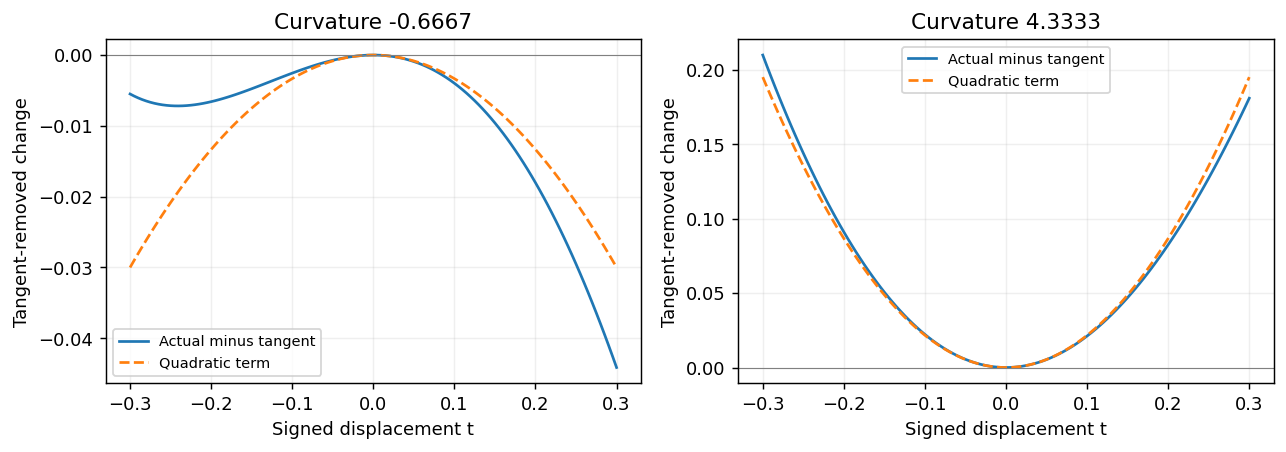

In [4]:
ts = np.linspace(-0.3, 0.3, 121)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for j, ax in enumerate(axes):
    u = V[:, j]
    values = [e.loss(theta+t*u, x, y)-L0-t*(g@u) for t in ts]
    ax.plot(ts, values, label="Actual minus tangent")
    ax.plot(ts, .5*eigenvalues[j]*ts**2, "--", label="Quadratic term")
    ax.axhline(0, color="gray", lw=.6)
    ax.set(xlabel="Signed displacement t", ylabel="Tangent-removed change", title=f"Curvature {eigenvalues[j]:.4f}")
    ax.legend(fontsize=8); ax.grid(alpha=.2)
fig.tight_layout(); show_png(fig)

### 3 椭圆与旋转二次曲面
特征值为1、16，q=1的半轴为√2、√2/4，长度比4。A 的二次型是精确函数，没有 Taylor 余项。

A =
 [[ 4.75       -6.49519053]
 [-6.49519053 12.25      ]]
spectrum = [ 1. 16.]
q=1 semiaxes = [1.41421356 0.35355339]


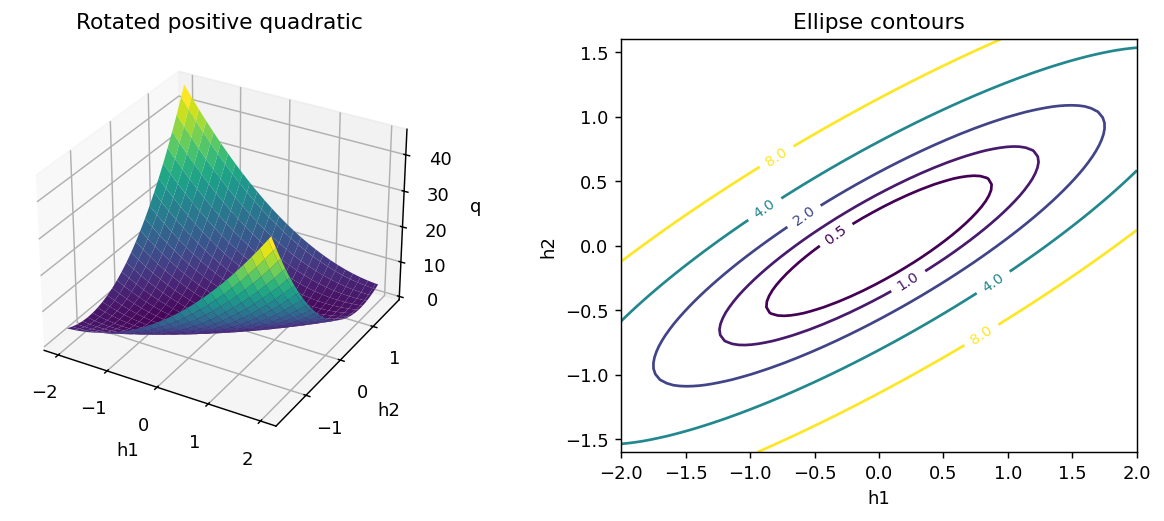

In [5]:
A, Q = e.rotated_quadratic()
print("A =\n", A)
print("spectrum =", np.linalg.eigvalsh(A))
print("q=1 semiaxes =", np.sqrt(2/np.array([1., 16.])))
u1, u2 = np.meshgrid(np.linspace(-2, 2, 80), np.linspace(-1.6, 1.6, 75))
q = .5*(A[0, 0]*u1**2 + 2*A[0, 1]*u1*u2 + A[1, 1]*u2**2)
fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(121, projection="3d")
ax.plot_surface(u1, u2, q, cmap="viridis", rcount=35, ccount=35)
ax.set(xlabel="h1", ylabel="h2", zlabel="q", title="Rotated positive quadratic")
ax = fig.add_subplot(122)
cs = ax.contour(u1, u2, q, levels=[.5, 1, 2, 4, 8])
ax.clabel(cs, fontsize=8); ax.set_aspect("equal")
ax.set(xlabel="h1", ylabel="h2", title="Ellipse contours")
fig.tight_layout(); show_png(fig)

### 4 驻点曲面与分类
先分 b=0 和 b≠0 求解全部驻点。报告中的 candidate 是数值候选；正文的精确代数负责证明梯度确为零。

base loss = 0.3958333333333333 spectrum = [-0.6666666666666665, 4.333333333333334] nonstationary
saddle loss = 0.6 spectrum = [-1.866666666666667, 3.3333333333333335] saddle_candidate
min_plus loss = 0.05555555555555555 spectrum = [1.073422053980167, 11.593244612686505] strict_local_minimum_candidate
min_minus loss = 0.05555555555555555 spectrum = [1.073422053980167, 11.593244612686505] strict_local_minimum_candidate


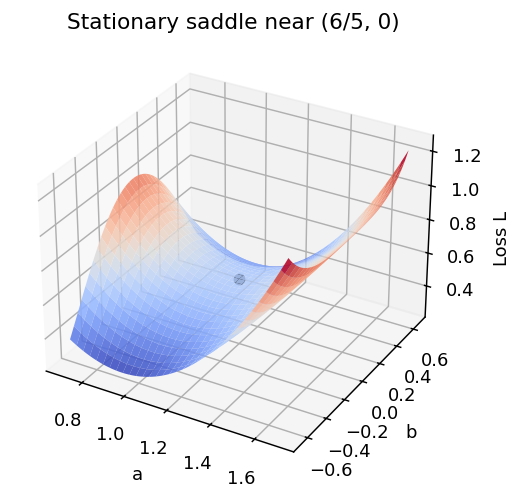

In [6]:
points = {"base": theta, "saddle": np.array([6/5, 0]),
          "min_plus": np.array([.5, np.sqrt(7/6)]), "min_minus": np.array([.5, -np.sqrt(7/6)])}
for name, point in points.items():
    result = e.classify(e.gradient(point, x, y), e.hessian(point, x, y))
    print(name, "loss =", e.loss(point, x, y), "spectrum =", result["eigenvalues"], result["conclusion"])
aa, bb = np.meshgrid(np.linspace(.7, 1.7, 65), np.linspace(-.65, .65, 65))
zz = (5/3)*aa**2 + 2*aa*bb**2 - 4*aa + bb**4 - (10/3)*bb**2 + 3
fig = plt.figure(figsize=(7.2, 4.4)); ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(aa, bb, zz, cmap="coolwarm", rcount=45, ccount=45, alpha=.88)
ax.scatter(6/5, 0, 3/5, c="black", s=30)
ax.set(xlabel="a", ylabel="b", zlabel="", title="Stationary saddle near (6/5, 0)")
ax.text2D(1.09, 0.55, "Loss L", transform=ax.transAxes, rotation=90, va="center")
show_png(fig)

### 5 半正定留下高阶问题
x²+y⁴、x²−y⁴、x² 在原点拥有相同梯度和 Hessian，但结论不同。零特征值时程序保留“不确定”。

{'gradient_within_tolerance': True, 'curvature': 'near_semidefinite_or_zero', 'conclusion': 'inconclusive', 'eigenvalues': [0.0, 2.0], 'eigenvectors_columns': [[0.0, 1.0], [1.0, 0.0]], 'eigenvalue_threshold': 2e-10, 'warning': '数值候选；不能证明梯度精确为零或邻域满足C2条件'}
Nearly zero negative eigenvalue: {'gradient_within_tolerance': True, 'curvature': 'near_semidefinite_or_zero', 'conclusion': 'inconclusive', 'eigenvalues': [-1e-12, 1.0], 'eigenvectors_columns': [[0.0, 1.0], [1.0, 0.0]], 'eigenvalue_threshold': 1e-10, 'warning': '数值候选；不能证明梯度精确为零或邻域满足C2条件'}


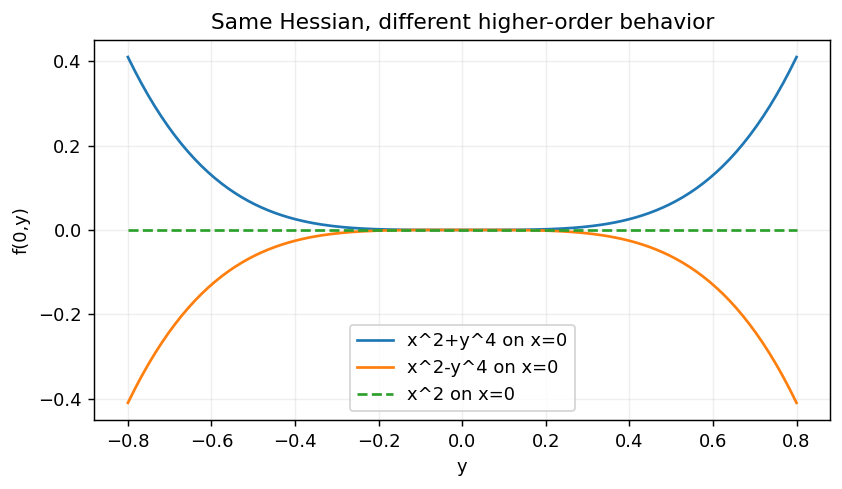

In [7]:
print(e.classify([0, 0], [[2, 0], [0, 0]]))
print("Nearly zero negative eigenvalue:", e.classify([0, 0], [[1, 0], [0, -1e-12]]))
t = np.linspace(-.8, .8, 201)
fig, ax = plt.subplots(figsize=(7.3, 3.8))
ax.plot(t, t**4, label="x^2+y^4 on x=0")
ax.plot(t, -t**4, label="x^2-y^4 on x=0")
ax.plot(t, np.zeros_like(t), "--", label="x^2 on x=0")
ax.set(xlabel="y", ylabel="f(0,y)", title="Same Hessian, different higher-order behavior")
ax.legend(); ax.grid(alpha=.2); show_png(fig)

### 6 测量近似误差
对单位方向(3/5,4/5)，预测 E₁/t²→5/3、E₂/t³→224/125。抵消方向(−1,1)/√2 的二阶余项为 t⁴/4。先看合理尺度，再观察浮点相减失效。

In [8]:
u = np.array([.6, .8])
for t in [.1, .01, .001]:
    h = t*u
    truth, p1, p2 = e.loss(theta+h, x, y), e.taylor(theta,h,x,y,1), e.taylor(theta,h,x,y,2)
    rem = e.exact_remainder(theta,h,x,y)
    print(f"t={t:g} truth={truth:.12g} E1={abs(truth-p1):.12g} E2={abs(truth-p2):.12g} polynomial_R2={rem:.12g}")
rows = e.error_sweep(x, y)
print("Normalized polynomial errors at smallest t:", rows[-1]["r1_over_t2"], rows[-1]["r2_over_t3"])


t=0.1 truth=0.337666293333 E1=0.0184996266667 E2=0.00183296 polynomial_R2=0.00183296
t=0.01 truth=0.388335129429 E1=0.000168462762667 E2=1.79609599987e-06 polynomial_R2=1.796096e-06
t=0.001 truth=0.395068335126 E1=1.66845907629e-06 E2=1.79240960962e-09 polynomial_R2=1.7924096e-09
Normalized polynomial errors at smallest t: 1.6666666666684586 1.79200000000041


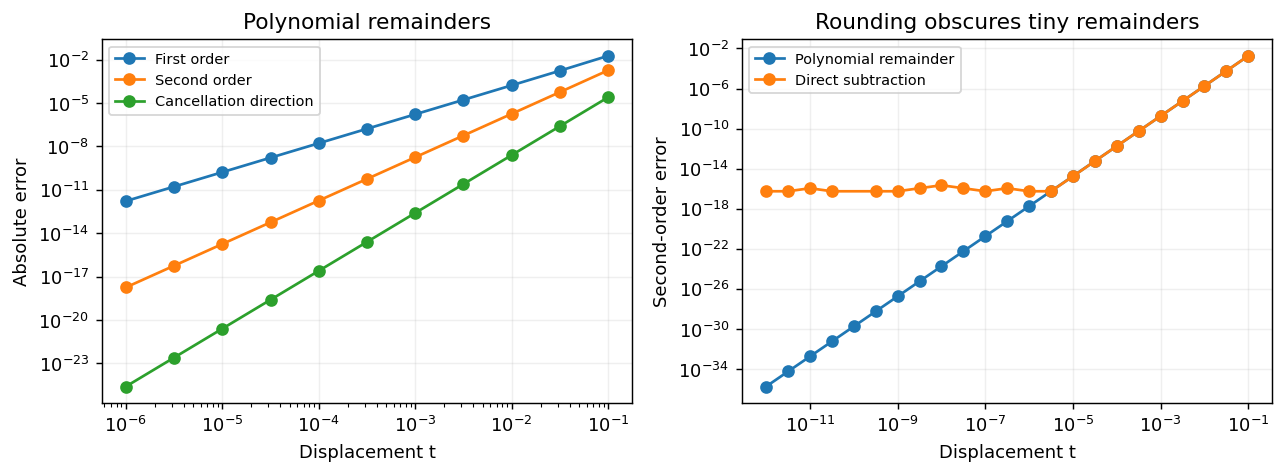

In [9]:
steps = np.array([r["step"] for r in rows])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for key, label in [("error1_polynomial", "First order"), ("error2_polynomial", "Second order"), ("cancel_error_polynomial", "Cancellation direction")]:
    values = np.array([r[key] for r in rows]); mask = steps >= 1e-6
    axes[0].loglog(steps[mask], values[mask], "o-", label=label)
axes[0].set(xlabel="Displacement t", ylabel="Absolute error", title="Polynomial remainders")
for key, label in [("error2_polynomial", "Polynomial remainder"), ("error2_subtraction", "Direct subtraction")]:
    values = np.array([r[key] for r in rows]); mask = values > 0
    axes[1].loglog(steps[mask], values[mask], "o-", label=label)
axes[1].set(xlabel="Displacement t", ylabel="Second-order error", title="Rounding obscures tiny remainders")
for ax in axes: ax.legend(fontsize=8); ax.grid(alpha=.2)
fig.tight_layout(); show_png(fig)

### 7 局部与全局分开证明
主模型的全局下界来自完成平方，不来自某一点正定的 Hessian。反例 F=x²+y²−2x⁴ 在原点严格局部极小，但 F(1,0)=−1。

In [10]:
def global_certificate(a, b):
    da, dc = a-.5, b*b-7/6
    return 1/18+(5/3)*(da+3*dc/5)**2+(2/5)*dc**2
for point in [theta, points["saddle"], points["min_plus"], np.array([-1., 2.])]:
    direct, certificate = e.loss(point, x, y), global_certificate(*point)
    print("point", point, "direct/certificate", direct, certificate)
    assert abs(direct-certificate) < 1e-12
print("Local-not-global example: F(0,0)=", 0., "F(1,0)=", 1.-2.)

point [1.  0.5] direct/certificate 0.3958333333333333 0.3958333333333334
point [1.2 0. ] direct/certificate 0.6 0.6000000000000002
point [0.5        1.08012345] direct/certificate 0.05555555555555555 0.05555555555555555
point [-1.  2.] direct/certificate 3.3333333333333335 3.333333333333333
Local-not-global example: F(0,0)= 0.0 F(1,0)= -1.0


### 8 统一步长要照顾每个特征方向
固定二次型从特征坐标(1,1)出发。0.1 的因子是0.9和−0.6；0.15的快方向因子为−1.4。

first step stable eigen-coordinates: [ 0.9 -0.6]
first step unstable eigen-coordinates: [ 0.85 -1.4 ]
20-step stable loss: 0.007390452164712935
20-step unstable loss: 5600301.573479728


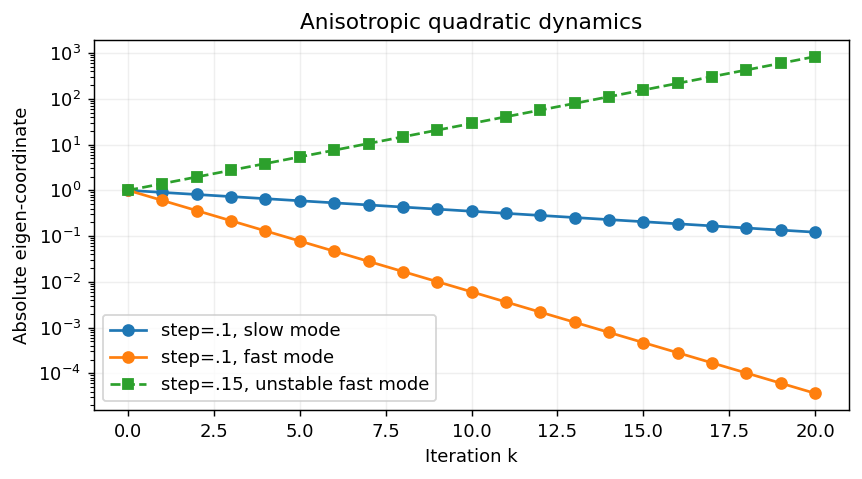

In [11]:
initial = Q @ np.array([1., 1.])
stable = e.quadratic_descent(A, initial, .1, 20)
unstable = e.quadratic_descent(A, initial, .15, 20)
print("first step stable eigen-coordinates:", Q.T@stable[1])
print("first step unstable eigen-coordinates:", Q.T@unstable[1])
print("20-step stable loss:", .5*e.quadratic_form(A, stable[-1]))
print("20-step unstable loss:", .5*e.quadratic_form(A, unstable[-1]))
fig, ax = plt.subplots(figsize=(7.5, 3.7)); k = np.arange(21)
ax.semilogy(k, abs((stable@Q)[:,0]), "o-", label="step=.1, slow mode")
ax.semilogy(k, abs((stable@Q)[:,1]), "o-", label="step=.1, fast mode")
ax.semilogy(k, abs((unstable@Q)[:,1]), "s--", label="step=.15, unstable fast mode")
ax.set(xlabel="Iteration k", ylabel="Absolute eigen-coordinate", title="Anisotropic quadratic dynamics")
ax.legend(); ax.grid(alpha=.2); show_png(fig)

## Checks 核验与故意失败
下格必须真的拒绝非法输入，不是把预期错误复制到输出。再运行完整25点与36组边界核查，并重新生成相对目录中的可再生结果。

In [12]:
cases = [("column theta", lambda: e.loss([[1],[.5]],x,y)),
         ("NaN", lambda: e.loss([1,np.nan],x,y)),
         ("asymmetric Hessian", lambda: e.classify([0,0],[[1,9],[0,1]])),
         ("unresolvable difference step", lambda: e.finite_hessian(theta,x,y,1e-20))]
for name, function in cases:
    try:
        function()
    except ValueError as error:
        print(name, "rejected:", error)
    else:
        raise AssertionError("Expected rejection: "+name)
report = e.run_all(write=True)
print("Full validation:", report["status"], "analytic points =", report["analytic_fd_points"], "boundary groups =", report["boundary_case_count"])
print("Maximum Hessian finite-difference error =", report["max_hessian_difference_error"])
print("Files:", [p.name for p in (e.BASE/"outputs").glob("*") if p.suffix in [".csv", ".json"]])

column theta rejected: theta 必须形状(2,)，不接收行列矩阵
NaN rejected: theta 必须有限
asymmetric Hessian rejected: H 不是给定容差内的对称矩阵；拒绝静默忽略一个三角区
unresolvable difference step rejected: 采样位移在当前尺度不可分辨
Full validation: passed analytic points = 25 boundary groups = 36
Maximum Hessian finite-difference error = 4.517204388321261e-10
Files: ['experiment_report.json', 'approximation_errors.csv', 'hessian_audit.csv']


## Next Steps 接下来

1. 从正文重新推导 C² 条件下的二阶 Peano 余项；不要把它擅自换成三阶界。
2. 给三个共享半正定 Hessian 的函数写出不同形状的直接证据。
3. 解释主点不定曲率为何不能证明驻点鞍点，再解释主模型全局下界来自哪里。
4. 完成独立实验记录，重启内核并从头运行全部。输出图为实际 PNG 图像；Notebook 不依赖图片网址或预先生成图文件。

程序的有限点检查不证明一般光滑性；梯度容差分类不等于精确驻点证明。局部坐标曲率不是完整优化难度指标。本实验没有训练/测试拆分或真实任务效果声明。

主要核对来源：[OpenStax 4.7](https://openstax.org/books/calculus-volume-3/pages/4-7-maxima-minima-problems)、[Conrad Taylor notes](https://math.stanford.edu/~conrad/diffgeomPage/handouts/higherderiv.pdf)、[NumPy eigh](https://numpy.org/doc/2.3/reference/generated/numpy.linalg.eigh.html)。详细来源记录与条件见 source-checks.json。